# Bias Simulation: Why more observations will not fix a biased estimate

Oftentimes, I hear in data science that the solution to have a better estimate is to include more observations. In my experience, this depends on *what exactly is better?* 
More observations typically yield higher power and lower estimate variance. However, this is half the story; forgetting to include a confounding factor will not fix the issue, no matter how many more observations we get. In this notebook, I will simulate a data-generating process and show this point.

For the sake of this example, I will simulate the following example for sales at stores receiving a random promotion:
 $$
\text{Advertising}_i \sim \text{Uniform}(0, 10)
$$$$
\text{Treatment}_i \sim \text{Bernoulli}\big(p_i\big), \quad p_i = \text{logit}^{-1}(2 - 0.4\cdot\text{Advertising}_i)
$$$$
\text{Price}_i = 3 + 2\cdot\text{Advertising}_i + \varepsilon_i^{(p)}, \quad \varepsilon^{(p)} \sim N(0,5)
$$$$
\text{Sales}_i = 60 - 3\cdot\text{Price}_i + 4\cdot\text{Advertising}_i + 6\cdot\text{Treatment}_i + \varepsilon^{(s)}_i, \quad \varepsilon^{(s)} \sim N(0,4)
$$

where   $\text{logit}^{-1}(x) = \frac{1}{1+e^{-x}}$, so units with higher advertising spend are systematically more likely to receive Treatment (e.g., at advertising=0, $p\approx12\%$; at advertising=10, $p\approx88\%$). This treatment could be promotion randomly assigned to stores), where the rule for assignment happens to correlate with ad expense. For example,  stores are randomly assigned to run a promotion, but marketing also tends to increase ad spend in weeks/stores that got the promotion (because promotions are usually bundled with an ad push).  


Now, Let's simulate this data


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
n = 100 #number of observations
np.random.seed(2026)
 
dataset = pd.DataFrame({"advertising":np.random.uniform(0,10,n),
                        "e_p":np.random.normal(loc=0,scale=5,size=n),
                        "e_s":np.random.normal(loc=0,scale=4,size=n)})

dataset['price']       = 3 + 2*dataset['advertising'] +dataset['e_p']
dataset['p']           = 1/(1+np.exp(2-0.4*dataset['advertising']))
dataset['treatment']   = np.random.binomial(1, dataset['p'])  
dataset['sale'] = 60 -3* dataset['price'] + 4 *dataset['advertising'] + 6*dataset['treatment']  + dataset['e_s']
print(dataset)
dataset.describe()

    advertising        e_p       e_s      price         p  treatment  \
0      2.193456  -0.943997  1.774090   6.442916  0.245526          0   
1      4.130117   2.078341 -4.777347  13.338576  0.413879          1   
2      9.766355  -0.558988  8.328260  21.973722  0.870630          1   
3      0.888990   3.613913 -8.295989   8.391894  0.161867          0   
4      4.792899   5.588108 -0.034416  18.173905  0.479302          0   
..          ...        ...       ...        ...       ...        ...   
95     9.744712  -4.009156 -5.388968  18.480267  0.869652          1   
96     9.252022   8.670765  9.800583  30.174810  0.845640          1   
97     6.125657  10.442349  5.467837  25.693663  0.610702          1   
98     8.905983  -1.473430  7.099756  19.338537  0.826696          1   
99     2.025984   0.747333 -0.907628   7.799301  0.233329          0   

         sale  
0   51.219168  
1   37.727394  
2   47.472514  
3   30.084291  
4   24.615464  
..        ...  
95  44.149078  
96  22.

,advertising,e_p,e_s,price,p,treatment,sale
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,4.997418,0.952646,0.336310,13.947482,0.497754,0.470000,41.303535
std,3.004162,4.667618,4.386825,7.910485,0.252001,0.501614,16.718091
min,0.023972,-10.398427,-9.355633,-4.038295,0.120213,0.000000,-11.655018
25%,2.323136,-2.110861,-2.558049,8.388806,0.255261,0.000000,29.934462
50%,4.847159,0.858512,0.680488,13.585357,0.484722,0.000000,43.201469
75%,7.406975,3.880591,3.789363,19.465133,0.723679,1.000000,51.465666
max,9.973985,13.598784,9.800583,30.681667,0.879700,1.000000,78.319456


In this case, advertising spend impacts both prices and the treatment, so omitting it would yield a biased estimate for the average treatment effect (6). In fact, we can tell the direction of the bias, given the properties of the OLS estimator. If the OLS estimate of the treatment in the omitted model  is denoted by $\hat{\gamma}_{treatment}$, on average it will be described by:
$$
\text{E}\{\hat{\gamma}_{treatment}\} = \beta_{treatment} + \beta_{advertisement} \cdot \delta_{treatment}
$$where $\delta_{treatment}$ is the coefficient from regressing the omitted variable on the included variable, so the bias itself is:$$
\text{Bias} = \beta_{advertising} \cdot \delta_{treatment}
$$

which is positive because  $\beta_{advertising}>0$ (more ad spend results in higher sales) and $\delta_{treatment}>0$ because units with higher advertising spend are systematically more likely to receive Treatment, as we set it in the simulation. 
Let's show this empirically below:

In [3]:
#Correct model
correct_model =  smf.ols(formula="sale ~ treatment+ price+ advertising", data=dataset).fit()
#Omitting advertisement spend
ommited_model =  smf.ols(formula="sale ~ treatment+ price", data=dataset).fit()
print(correct_model.summary())

print(ommited_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   sale   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     452.3
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           1.75e-56
Time:                        08:57:44   Log-Likelihood:                -287.19
No. Observations:                 100   AIC:                             582.4
Df Residuals:                      96   BIC:                             592.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      61.0031      0.911     66.956      

# Will increasing the sample size (adding more treated units) result in this Bias being corrected?

Theoretically, the answer is no, because $ \beta_{advertising} \cdot \delta_{treatment}$ does not converge to zero, no matter how big our sample becomes, which is why adding more units does not solve the problem. Let's show this empirically by writing a function to simulate multiple experiments, and then plotting the coefficient of interest. The graph below shows this exactly: no matter how many more stores we run the promotion for, if we do not control for the ad expenditure for each store, the bias never cancels.

In [4]:
def simulate_experiments(obs=30 ):
    data = pd.DataFrame({"advertising":np.random.uniform(0,10,obs),
                        "e_p":np.random.normal(loc=0,scale=5,size=obs),
                        "e_s":np.random.normal(loc=0,scale=4,size=obs)})

    data['price']       = 3 + 2*data['advertising'] +data['e_p']
    data['p']           = 1/(1+np.exp(2-0.4*data['advertising']))
    data['treatment']   = np.random.binomial(1, data['p'])  
    data['sale']        = 60 -3* data['price'] + 4 *data['advertising'] + 6*data['treatment']  + data['e_s']
    #Well specified
    correct_model =  smf.ols(formula="sale ~ treatment+ price+ advertising", data=data).fit()
    #Omitting advertisement spend
    ommited_model =  smf.ols(formula="sale ~ treatment+ price", data=data).fit()
    result = {'correct':correct_model,
             'ommited':ommited_model}
    return result

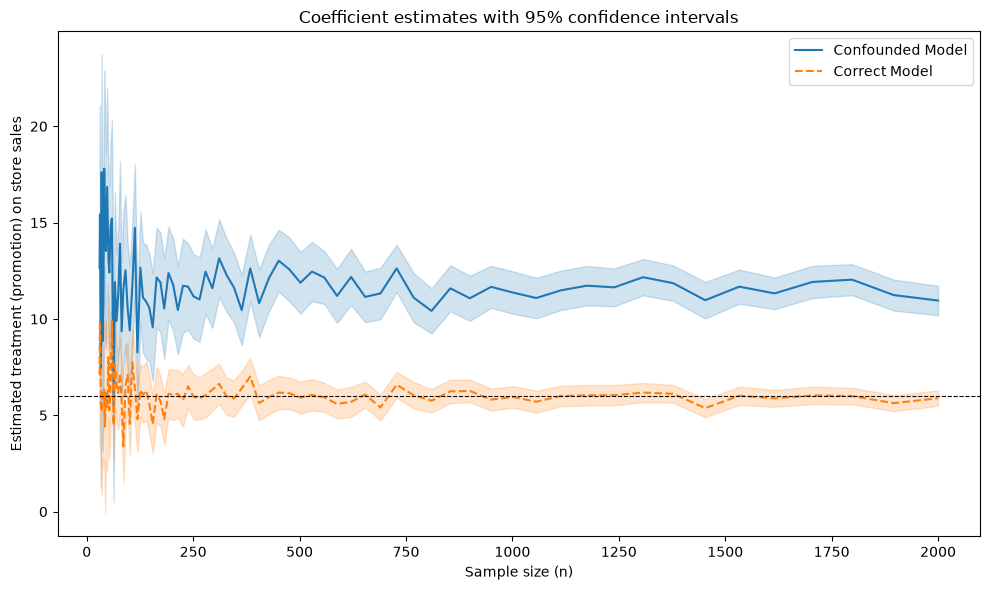

In [8]:
#Test the function

check_sim = simulate_experiments(100)
check_sim['correct'].params['treatment']
check_sim['correct'].conf_int()

#Now simulate (80 experiments starting at 30 and ending at 2000)
experiments = 80
results =   pd.DataFrame(
    index=range(experiments),
    columns=["n", "coef", "ci_lower", "ci_upper","coef_correct","ci_lower_correct", "ci_upper_correct"],
    dtype=float
)
idx = 0 
for i in np.unique(np.geomspace(30, 2000, num=experiments).astype(int)):
    experiment = simulate_experiments(i)
    results.loc[idx,'n']                = i
    results.loc[idx,'coef']             = experiment['ommited'].params['treatment']
    results.loc[idx,'ci_lower']         = experiment['ommited'].conf_int().loc['treatment',0] 
    results.loc[idx,'ci_upper']         = experiment['ommited'].conf_int().loc['treatment',1] 
    results.loc[idx,'coef_correct']     = experiment['correct'].params['treatment']
    results.loc[idx,'ci_lower_correct'] = experiment['correct'].conf_int().loc['treatment',0]
    results.loc[idx,'ci_upper_correct'] = experiment['correct'].conf_int().loc['treatment',1]
    idx = idx +1
results  

fig, ax = plt.subplots(figsize=(10, 6))
 
# Misspecified model
ax.plot(results['n'], results['coef'], label='Confounded Model', color='C0')
ax.fill_between(results['n'], results['ci_lower'], results['ci_upper'],
                 color='C0', alpha=0.2)
 
# Correct model
ax.plot(results['n'], results['coef_correct'], label='Correct Model',  color='C1', linestyle='--')
ax.fill_between(results['n'], results['ci_lower_correct'], results['ci_upper_correct'],
                 color='C1', alpha=0.2)
 
ax.axhline(6, color='black', linewidth=0.8, linestyle='--')  # optional reference line at 0
ax.set_xlabel('Sample size (n)')
ax.set_ylabel('Estimated treatment (promotion) on store sales')
ax.set_title('Coefficient estimates with 95% confidence intervals')
ax.legend()
 
plt.tight_layout()
 
plt.savefig("G:/My Drive/Projects/Bias Simulation/bias_sim.png", dpi=300, bbox_inches='tight')
plt.show()